# RAG Price Estimator — Actual vs. Estimated

Loads `rag_eval_results.csv` (produced by `evaluate_rag_estimator.py`) and
plots actual price vs. estimated price twice: once on a regular (linear)
scale and once in log space, so a wide price range doesn't hide how the
cheap end of the distribution behaves.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Adjust this if your CSV lives somewhere else relative to this notebook
CSV_PATH = "eval/rag_eval_results.csv"

df = pd.read_csv(CSV_PATH)
df.head()

,project_id,actual_price_tomans,estimated_price_tomans,reasoning
0,0bdb5ad9-d894-45c9-ba7f-7f3750b31425,5.329967e+05,1508800.0,این مشکل مربوط به تنظیمات Gradle و دانلود لایب...
1,60de0741-932b-49c6-952e-03add83b34c8,3.231573e+07,33948000.0,با توجه به اینکه فرانت‌اند آماده است و پروژه ص...
2,55d61cf4-de41-4ce0-847a-58cab3c54f71,7.197374e+07,84870000.0,با توجه به نیاز به تیم (PHP و CSS)، انتقال از ...
3,a2dd937e-c8fe-4cb4-acea-67fde0d537d6,3.252706e+07,85000000.0,با توجه به شباهت پروژه «راوی» به پلتفرم‌های کا...
4,2281b4a4-22a7-4a3e-998c-0e8b8b062e43,6.719416e+06,51865000.0,با توجه به نیاز به بازنویسی و پیاده‌سازی ۴ الگ...


## Clean up

Drop rows with missing or non-positive prices — they can't be shown on a
log-scale plot anyway, and they'd have failed the eval script's own
price check to begin with (this is just a safety net).

In [2]:
before = len(df)
df = df.dropna(subset=["actual_price_tomans", "estimated_price_tomans"])
df = df[(df["actual_price_tomans"] > 0) & (df["estimated_price_tomans"] > 0)]
after = len(df)
print(f"kept {after}/{before} rows")

df["abs_error"] = (df["estimated_price_tomans"] - df["actual_price_tomans"]).abs()
df["pct_error"] = df["abs_error"] / df["actual_price_tomans"] * 100

print(f"MAE:  {df['abs_error'].mean():,.0f} tomans")
print(f"MAPE: {df['pct_error'].mean():.1f}%")
print(f"Median APE: {df['pct_error'].median():.1f}%")

kept 296/296 rows
MAE:  11,194,778 tomans
MAPE: 509.0%
Median APE: 72.2%


## Linear scale

Straightforward actual vs. estimated scatter. The dashed line is
`y = x` — a perfect estimate lands exactly on it. Points above the line
are over-estimates, points below are under-estimates.

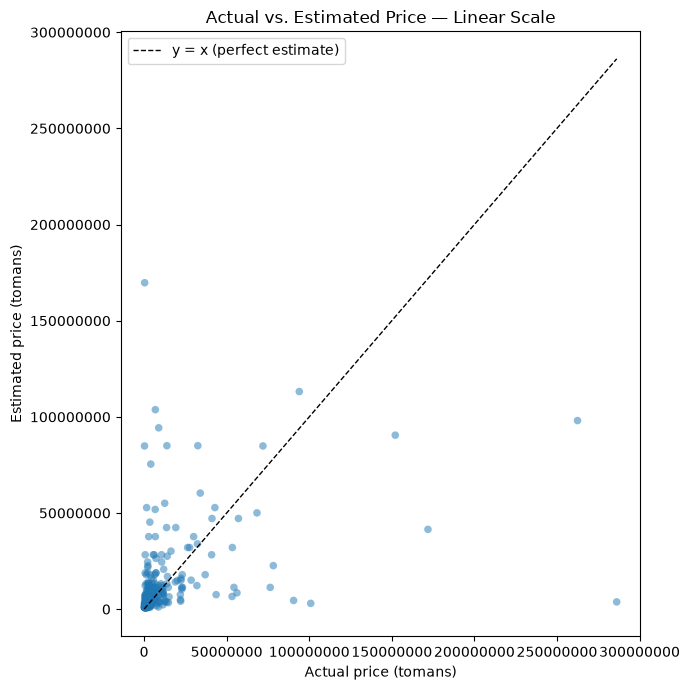

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(df["actual_price_tomans"], df["estimated_price_tomans"],
           alpha=0.5, edgecolors="none", s=30)

lo = min(df["actual_price_tomans"].min(), df["estimated_price_tomans"].min())
hi = max(df["actual_price_tomans"].max(), df["estimated_price_tomans"].max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x (perfect estimate)")

ax.set_xlabel("Actual price (tomans)")
ax.set_ylabel("Estimated price (tomans)")
ax.set_title("Actual vs. Estimated Price — Linear Scale")
ax.legend()
ax.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()

## Log space

Same data, both axes log-scaled. Freelance project prices tend to span
a couple of orders of magnitude, so this view keeps cheap projects from
being crushed into the corner and makes relative (percentage) error
easier to eyeball — equal vertical distance from the `y = x` line now
means roughly equal relative error, not equal absolute error.

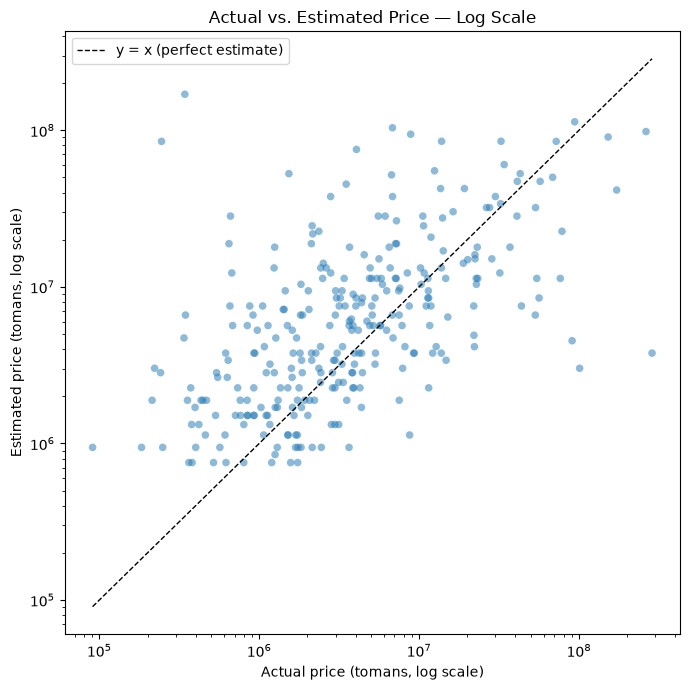

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(df["actual_price_tomans"], df["estimated_price_tomans"],
           alpha=0.5, edgecolors="none", s=30)

lo = min(df["actual_price_tomans"].min(), df["estimated_price_tomans"].min())
hi = max(df["actual_price_tomans"].max(), df["estimated_price_tomans"].max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x (perfect estimate)")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual price (tomans, log scale)")
ax.set_ylabel("Estimated price (tomans, log scale)")
ax.set_title("Actual vs. Estimated Price — Log Scale")
ax.legend()
plt.tight_layout()
plt.show()

## Error distribution (bonus)

Percentage error per project, sorted — a quick way to see how often the
estimator is close vs. wildly off, independent of absolute price.

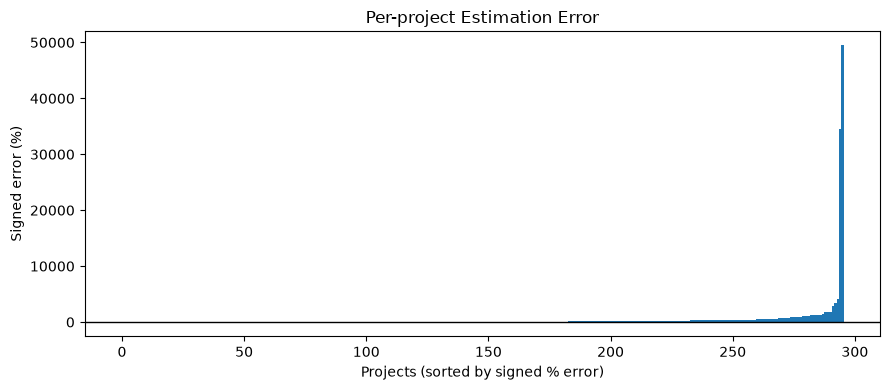

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

signed_pct_error = ((df["estimated_price_tomans"] - df["actual_price_tomans"])
                     / df["actual_price_tomans"] * 100).sort_values().reset_index(drop=True)

ax.bar(range(len(signed_pct_error)), signed_pct_error, width=1.0)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Projects (sorted by signed % error)")
ax.set_ylabel("Signed error (%)")
ax.set_title("Per-project Estimation Error")
plt.tight_layout()
plt.show()